In [1]:
import numpy as np
import pickle
import math
from scipy.stats import sem
import matplotlib.pyplot as plt
import pandas as pd
import time
import pprint
import seaborn as sns
import statsmodels.formula.api as smf
import CMR_IA as cmr
import scipy as sp
import sys

sys.path.append("../../Modeling/fitting")
from optimization_utils import make_boundary

In [2]:
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVERES = False

## Load Stimuli and Semantic Matrix

In [3]:
with open("simu4_data/simu4_design.pkl", "rb") as inp:
    df_study = pickle.load(inp)
    df_test = pickle.load(inp)

In [4]:
# df_study = df_study.loc[df_study.session < 100]  # for testing
df_study

,itemno,item,itemno_old,freq,quantile,session,list
0,316,FARM,552,1161,8,0,0
1,477,LEOPARD,812,118,3,0,0
2,433,INSTRUCTOR,741,78,2,0,0
3,87,BOTTLE,153,1479,8,0,0
4,84,BOOT,150,149,3,0,0
...,...,...,...,...,...,...,...
99995,895,TOWN,1491,3328,9,999,0
99996,633,PIANO,1057,466,6,999,0
99997,843,SUBMARINE,1398,154,3,999,0
99998,462,LABYRINTH,791,32,0,999,0


In [5]:
# df_test = df_test.loc[df_test.session < 100]  # for testing
df_test

,itemno,item,itemno_old,freq,quantile,session,list,position,old
0,341,FORT,595,411,6,0,0,0,True
1,512,MANSION,864,156,3,0,0,1,True
2,66,BENCH,121,345,6,0,0,2,True
3,386,GUARD,667,658,7,0,0,3,False
4,57,BEE,112,185,4,0,0,4,True
...,...,...,...,...,...,...,...,...,...
199995,503,LUNG,850,169,4,999,0,195,True
199996,891,TORNADO,1485,34,0,999,0,196,False
199997,932,VEHICLE,1553,383,6,999,0,197,False
199998,735,RUG,1215,321,5,999,0,198,True


In [6]:
s_mat = np.load("simu4_data/simu4_smat.npy")

## Run CMR-IA

In [7]:
# define parameters
params = cmr.make_default_params()
params.update(use_new_context=True, beta_distract=0)

# load pso results
_, _, what_to_fit = make_boundary(sim_name="4")
optim_params = np.loadtxt("simu4_data/4shift_250228_200-200.txt")
for pname, pvalue in zip(what_to_fit, optim_params):
    params[pname] = pvalue
params

{'beta_enc': 0.824638,
 'beta_rec': 0.5,
 'beta_cue': 0.04799,
 'beta_rec_post': 0.5,
 'beta_distract': 0,
 'phi_s': 2,
 'phi_d': 0.5,
 's_cf': 0,
 's_fc': 0.184317,
 'kappa': 0.5,
 'eta': 0.5,
 'omega': 5,
 'alpha': 1,
 'lamb': 0.5,
 'c_thresh': 0.5,
 'c_thresh_itm': -0.03743,
 'c_thresh_assoc': 0.5,
 'd_assoc': 1,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 50,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 3.424778,
 'thresh_sigma': 0,
 'ban_recall': None,
 'var_enc': 1,
 'bad_enc_ratio': 1,
 'recog_slope': 1,
 'a': 2800,
 'b': 20,
 'gamma_fc': 0.779302,
 'gamma_cf': 0.5}

In [8]:
# # define parameters - copy from pso fitting
# params = cmr.make_default_params()
# params.update(
#     beta_enc=0.0233645,
#     beta_cue=0.93350279,
#     beta_distract=0.14106648,
#     gamma_fc=0.75152814,
#     s_fc=0.08476893,
#     c_thresh_itm=0.12888085,
#     use_new_context=True,
# )
# params

In [9]:
# run the model
df_simu = cmr.run_norm_recog_multi_sess(params, df_study, df_test, s_mat)
df_simu

100%|██████████| 1000/1000 [01:07<00:00, 14.89it/s]


CMR Time: 67.20355892181396


,session,list,itemno,s_resp,s_rt,csim,prob
0,0,0,341,0.0,17.338425,0.216792,0.469280
1,0,0,512,0.0,7.536972,0.258448,0.481772
2,0,0,66,0.0,41.470976,0.173189,0.481420
3,0,0,386,0.0,224.112663,0.088831,0.468768
4,0,0,57,0.0,0.938128,0.362632,0.496461
...,...,...,...,...,...,...,...
199995,999,0,503,1.0,0.179920,0.445201,0.536065
199996,999,0,891,1.0,8.096293,0.254868,0.500030
199997,999,0,932,1.0,1.108686,0.354280,0.503604
199998,999,0,735,1.0,0.067417,0.494281,0.520480


In [10]:
# merge to get more info
df_simu = df_simu.merge(df_test, on=["session", "list", "itemno"])
df_simu

,session,list,itemno,s_resp,s_rt,csim,prob,item,itemno_old,freq,quantile,position,old
0,0,0,341,0.0,17.338425,0.216792,0.469280,FORT,595,411,6,0,True
1,0,0,512,0.0,7.536972,0.258448,0.481772,MANSION,864,156,3,1,True
2,0,0,66,0.0,41.470976,0.173189,0.481420,BENCH,121,345,6,2,True
3,0,0,386,0.0,224.112663,0.088831,0.468768,GUARD,667,658,7,3,False
4,0,0,57,0.0,0.938128,0.362632,0.496461,BEE,112,185,4,4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,999,0,503,1.0,0.179920,0.445201,0.536065,LUNG,850,169,4,195,True
199996,999,0,891,1.0,8.096293,0.254868,0.500030,TORNADO,1485,34,0,196,False
199997,999,0,932,1.0,1.108686,0.354280,0.503604,VEHICLE,1553,383,6,197,False
199998,999,0,735,1.0,0.067417,0.494281,0.520480,RUG,1215,321,5,198,True


In [11]:
if SAVERES:
    df_simu.to_pickle("simu4_data/simu4_result_ctrl.pkl")

## Analysis

In [12]:
# with open("simu4_data/simu4_result_ctrl.pkl", "rb") as inp:
#     df_simu = pickle.load(inp)

In [13]:
df_simu.groupby(["old"]).s_resp.mean()

old
False    0.16428
True     0.88382
Name: s_resp, dtype: float64

In [14]:
# get wordfreq quantile
with open("simu4_data/simu4_word_freq.pkl", "rb") as inp:
    df = pickle.load(inp)
df

,item,itemno_old,itemno,freq,quantile
0,ABDOMEN,1,1,110,2
1,ACROBAT,4,2,17,0
2,ADULT,8,3,906,8
3,ALLEY,15,4,165,4
4,ALLIGATOR,16,5,12,0
...,...,...,...,...,...
979,YOKE,1632,980,12,0
980,YOLK,1633,981,47,1
981,YOUTH,1634,982,1159,8
982,ZIPPER,1636,983,24,0


In [15]:
# check mean frequency of each group
freq_mean = df.groupby("quantile").freq.mean().to_numpy()
freq_mean = np.around(freq_mean, decimals=0)
freq_mean

array([  21.,   51.,   90.,  141.,  196.,  284.,  415.,  632., 1163.,
       4332.])

### Csim

In [16]:
# check the recognition threshold for each group
s_mean = np.mean(s_mat, axis=1)
c_vec_cal = params["c_s"] * s_mean + params["c_thresh_itm"]
df["c_vec"] = c_vec_cal
df.groupby("quantile").c_vec.mean()

quantile
0    0.361079
1    0.373010
2    0.355606
3    0.344366
4    0.342973
5    0.332152
6    0.326539
7    0.314031
8    0.297150
9    0.297438
Name: c_vec, dtype: float64

In [17]:
# separate hf and lf
create_level = {0: "new lf", 1: "new hf", 2: "old lf", 3: "old hf"}
df_simu["hf"] = df_simu["quantile"] >= 5
df_simu["level"] = df_simu.apply(lambda x: create_level[x["old"] * 2 + x["hf"]], axis=1)
df_simu

,session,list,itemno,s_resp,s_rt,csim,prob,item,itemno_old,freq,quantile,position,old,hf,level
0,0,0,341,0.0,17.338425,0.216792,0.469280,FORT,595,411,6,0,True,True,old hf
1,0,0,512,0.0,7.536972,0.258448,0.481772,MANSION,864,156,3,1,True,False,old lf
2,0,0,66,0.0,41.470976,0.173189,0.481420,BENCH,121,345,6,2,True,True,old hf
3,0,0,386,0.0,224.112663,0.088831,0.468768,GUARD,667,658,7,3,False,True,new hf
4,0,0,57,0.0,0.938128,0.362632,0.496461,BEE,112,185,4,4,True,False,old lf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,999,0,503,1.0,0.179920,0.445201,0.536065,LUNG,850,169,4,195,True,False,old lf
199996,999,0,891,1.0,8.096293,0.254868,0.500030,TORNADO,1485,34,0,196,False,False,new lf
199997,999,0,932,1.0,1.108686,0.354280,0.503604,VEHICLE,1553,383,6,197,False,True,new hf
199998,999,0,735,1.0,0.067417,0.494281,0.520480,RUG,1215,321,5,198,True,True,old hf


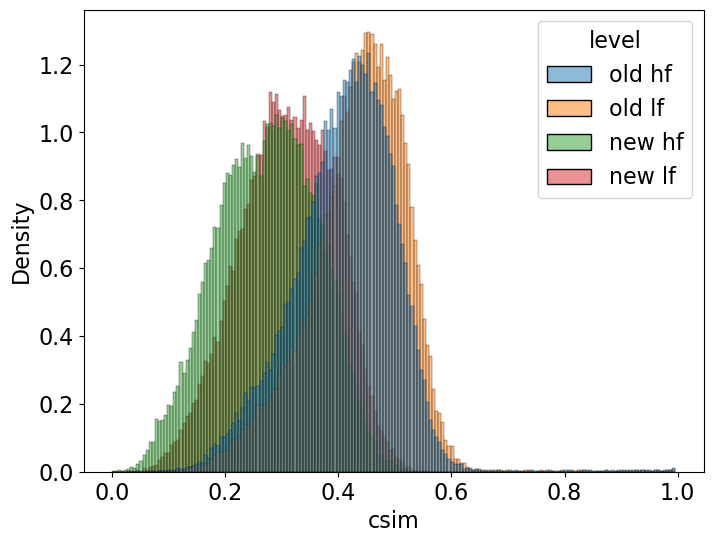

In [18]:
# plot the csim distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(df_simu, x="csim", hue="level", alpha=0.5, ax=ax, stat="density")
plt.show()

In [19]:
# check the csim of each group
df_tmp = df_simu.groupby(["old", "quantile"]).csim.mean().to_frame().reset_index()
df_tmp = pd.pivot_table(data=df_tmp, values="csim", columns="old", index="quantile").reset_index()
df_tmp["True-False"] = df_tmp[True] - df_tmp[False]
df_tmp["c_vec"] = df.groupby("quantile").c_vec.mean()
df_tmp

old,quantile,False,True,True-False,c_vec
0,0,0.315968,0.441254,0.125286,0.361079
1,1,0.324139,0.445230,0.121090,0.373010
2,2,0.310227,0.434881,0.124654,0.355606
3,3,0.300330,0.429977,0.129647,0.344366
4,4,0.299762,0.427959,0.128197,0.342973
5,5,0.289621,0.421789,0.132168,0.332152
6,6,0.286274,0.418656,0.132382,0.326539
7,7,0.275621,0.412944,0.137323,0.314031
8,8,0.261634,0.401802,0.140168,0.297150
9,9,0.258059,0.399864,0.141805,0.297438


### Yes Rate

In [20]:
# session-wise, get yes rate for each condition
df_sess_q = df_simu.groupby(["session", "quantile", "old"]).s_resp.mean().to_frame(name="yes_rate").reset_index()
df_sess_q

,session,quantile,old,yes_rate
0,0,0,False,0.111111
1,0,0,True,0.875000
2,0,1,False,0.230769
3,0,1,True,0.909091
4,0,2,False,0.000000
...,...,...,...,...
19995,999,7,True,0.727273
19996,999,8,False,0.250000
19997,999,8,True,0.909091
19998,999,9,False,0.500000


In [21]:
# collapse across session
df_q = df_sess_q.groupby(["quantile", "old"]).yes_rate.mean().to_frame().reset_index()
df_q

,quantile,old,yes_rate
0,0,False,0.136803
1,0,True,0.869982
2,1,False,0.138684
3,1,True,0.853395
4,2,False,0.150099
5,2,True,0.863882
6,3,False,0.137692
7,3,True,0.880681
8,4,False,0.168537
9,4,True,0.874198


In [22]:
df_q.query("old == True")["yes_rate"].values

array([0.86998243, 0.85339463, 0.86388159, 0.88068131, 0.87419783,
       0.88502509, 0.89075871, 0.89953788, 0.91066524, 0.90768635])

In [23]:
# format df for plotting
df_plot = pd.pivot_table(df_q, values="yes_rate", index="quantile", columns="old").reset_index()
df_plot.rename(columns={False: "far", True: "hr"}, inplace=True)
df_plot["freq_mean"] = freq_mean
df_plot

old,quantile,far,hr,freq_mean
0,0,0.136803,0.869982,21.0
1,1,0.138684,0.853395,51.0
2,2,0.150099,0.863882,90.0
3,3,0.137692,0.880681,141.0
4,4,0.168537,0.874198,196.0
5,5,0.166824,0.885025,284.0
6,6,0.164768,0.890759,415.0
7,7,0.185684,0.899538,632.0
8,8,0.206131,0.910665,1163.0
9,9,0.178618,0.907686,4332.0


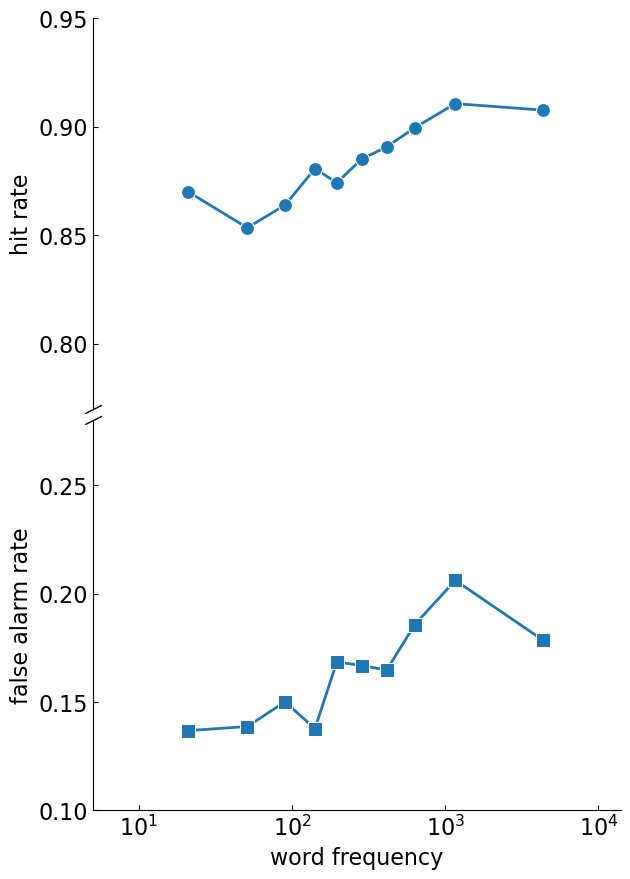

In [24]:
# plot
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 9))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)
fig.subplots_adjust(hspace=0.03)

sns.lineplot(data=df_plot, y="hr", x="freq_mean", ax=ax1, marker="o", color="C0", markersize=10, linewidth=2)
sns.lineplot(data=df_plot, y="far", x="freq_mean", ax=ax2, marker="s", color="C0", markersize=10, linewidth=2)

ax1.set_ylim(0.77, 0.95)
ax1.set_yticks(np.arange(0.80, 0.96, 0.05))
ax2.set_ylim(0.1, 0.28)
ax2.set_yticks(np.arange(0.1, 0.30, 0.05))
ax1.tick_params(axis="y", direction="in")
ax1.tick_params(axis="x", direction="in")
ax2.tick_params(axis="y", direction="in")
ax2.tick_params(axis="x", direction="in")
plt.xscale("log")
plt.xlim(5, 14000)

ax1.spines.bottom.set_visible(False)
ax1.spines.top.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.spines.right.set_visible(False)
ax2.spines.right.set_visible(False)
ax1.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False, labeltop=False)
ax2.minorticks_off()

d = 0.5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle="none", color="k", mec="k", mew=1, clip_on=False)
ax1.plot(0, 0, transform=ax1.transAxes, **kwargs)
ax2.plot(0, 1, transform=ax2.transAxes, **kwargs)

ax1.set_ylabel("hit rate")
ax2.set_ylabel("false alarm rate")
ax2.set_xlabel("word frequency")

# plt.tight_layout(h_pad = 0)
if SAVEFIG:
    ax1.set_ylabel(None)
    ax1.set_xlabel(None)
    ax2.set_ylabel(None)
    ax2.set_xlabel(None)
    ax1.tick_params(labelleft=False)
    ax2.tick_params(labelleft=False)
    plt.savefig("simu4_fig/simu4_WFE_ctrl.pdf")
plt.show()

### d-prime

In [25]:
# session-wise, get z yes rate for each condition
df_sess_q_adj = df_simu.groupby(["session", "quantile", "old"]).s_resp.aggregate(["sum", "count"]).reset_index()
df_sess_q_adj["yes_rate_adj"] = (df_sess_q_adj["sum"] + 0.5) / (df_sess_q_adj["count"] + 1)
df_sess_q_adj["z_yes_rate"] = sp.stats.norm.ppf(df_sess_q_adj["yes_rate_adj"])
df_sess_q_adj

,session,quantile,old,sum,count,yes_rate_adj,z_yes_rate
0,0,0,False,1.0,9,0.150000,-1.036433
1,0,0,True,7.0,8,0.833333,0.967422
2,0,1,False,3.0,13,0.250000,-0.674490
3,0,1,True,10.0,11,0.875000,1.150349
4,0,2,False,0.0,13,0.035714,-1.802743
...,...,...,...,...,...,...,...
19995,999,7,True,8.0,11,0.708333,0.548522
19996,999,8,False,2.0,8,0.277778,-0.589456
19997,999,8,True,10.0,11,0.875000,1.150349
19998,999,9,False,5.0,10,0.500000,0.000000


In [26]:
# collapse across session
df_q_adj = df_sess_q_adj.groupby(["quantile", "old"]).z_yes_rate.mean().to_frame().reset_index()
df_q_adj = pd.pivot_table(df_q_adj, values="z_yes_rate", index="quantile", columns="old").reset_index()
df_q_adj.rename(columns={False: "z_far", True: "z_hr"}, inplace=True)
df_q_adj["dprime"] = df_q_adj["z_hr"] - df_q_adj["z_far"]
df_q_adj["freq_mean"] = freq_mean
df_q_adj

old,quantile,z_far,z_hr,dprime,freq_mean
0,0,-1.026731,1.045327,2.072057,21.0
1,1,-1.023185,0.995774,2.018959,51.0
2,2,-0.989560,1.047859,2.037420,90.0
3,3,-1.031272,1.103512,2.134784,141.0
4,4,-0.913573,1.069813,1.983386,196.0
5,5,-0.925523,1.115032,2.040555,284.0
6,6,-0.924267,1.138642,2.062909,415.0
7,7,-0.861140,1.173045,2.034186,632.0
8,8,-0.792690,1.218753,2.011442,1163.0
9,9,-0.878912,1.211515,2.090427,4332.0


### Error Check

In [27]:
with open("simu4_data/simu4_gt.pkl", "rb") as f:
    hr_gt = pickle.load(f)
    far_gt = pickle.load(f)
hr_gt, far_gt

(array([0.90287356, 0.88502554, 0.88761973, 0.88043582, 0.87863985,
        0.87963761, 0.86965996, 0.86187739, 0.84172254, 0.83693327]),
 array([0.11368631, 0.13186813, 0.14265734, 0.16373626, 0.17142857,
        0.18301698, 0.18661339, 0.19320679, 0.19150849, 0.19280719]))

In [28]:
# Get behavioral stats and compare with ground truth
hr = df_q.query("old == True")["yes_rate"].values
far = df_q.query("old == False")["yes_rate"].values
err = np.power(hr - hr_gt, 2).sum() + np.power(far - far_gt, 2).sum()
err

0.01685124106966744